<a href="https://colab.research.google.com/github/thx1173/cwiczene_git/blob/main/Grupa_4_dataPreprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Data Preprocessing. dr inż. Karol Flisikowski.**

Ćwiczenie zaliczeniowe. Grupa4: Andrzej Zieliński.

Z uwagi na brak kontaktu z pozostałymi członkami grupy i zaplanowany wyjazd nad zadaniem pracowałem samodzielnie.

Baza danych: apartments_rent_pl_2023_12.csv


Celem zadania jest przygotowanie surowych danych w następujących krokach: ocena jakości danych wejściowych anastępnie ich: oczyszczenie, uporządkowanie i przekształcenie tak w kolejnych krokach była możliwa ich dalsza analiza i interpretacja.

Przyjetą zmoenną zależńą, która w dalszej perspektywie będzie podlegała analizie jest cena 'price'.

In [3]:
# W pierwszym kroku importujemy wszystkie niezbędne biblioteki python
import seaborn as sns
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt


In [4]:
# Następnie wczytujemy plik danych dotyczących apartamentów do wynajęcia z pliku csv: apartments_rent_pl_2023_12.csv zawierający wszystkie miasta w danym miesiącu
df_all = pd.read_csv('https://raw.githubusercontent.com/kflisikowsky/analiza_danych_projekt_zespolowy/refs/heads/main/Nieruchomosci%20w%20Polsce/apartments_rent_pl_2023_12.csv')
df_all

,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,...,pharmacyDistance,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price
0,c63a4bfb4e073634d5d2841eff4448d4,szczecin,NaN,65.00,2.0,3.0,4.0,NaN,53.428544,14.552812,...,0.085,condominium,NaN,NaN,no,no,no,no,no,2200
1,98ee431da834e6c7944b315f39ee7846,szczecin,blockOfFlats,43.04,2.0,4.0,4.0,1965.0,53.434000,14.551800,...,0.116,condominium,NaN,NaN,yes,yes,no,no,no,2100
2,2a1a6db97ff122d6bc148abb6f0e498a,szczecin,blockOfFlats,52.00,2.0,3.0,3.0,2008.0,53.460535,14.545416,...,0.307,condominium,brick,NaN,yes,yes,no,no,no,3500
3,693e851f34d2f621e8b458517ce4a6df,szczecin,blockOfFlats,40.00,2.0,1.0,5.0,NaN,53.417761,14.542467,...,0.220,condominium,NaN,premium,yes,yes,yes,yes,no,2350
4,a6947320455a7f8afd2d53497a5b47e9,szczecin,blockOfFlats,70.00,3.0,1.0,2.0,2000.0,53.442188,14.486052,...,0.273,condominium,brick,NaN,yes,no,no,no,no,3200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8867,e9c0f3ca8fd42bc4c8b07ef2a5c53d2e,bydgoszcz,tenement,53.00,3.0,1.0,4.0,NaN,53.126000,18.007900,...,0.205,condominium,brick,NaN,no,no,no,no,no,2190
8868,89fdf9ecda6fe6aa95e34528fa82f55f,bydgoszcz,blockOfFlats,48.00,2.0,3.0,3.0,2019.0,53.121200,17.992500,...,0.300,condominium,brick,NaN,no,no,no,no,no,2700
8869,095b187d0bbce092d4b03164e89710c5,bydgoszcz,blockOfFlats,50.00,2.0,1.0,3.0,2019.0,53.121200,17.992500,...,0.300,condominium,brick,NaN,no,yes,no,no,no,2800
8870,eee39c309b4f55e057485d848bb2772b,bydgoszcz,NaN,40.00,2.0,1.0,1.0,NaN,53.126000,18.007900,...,0.205,condominium,NaN,NaN,no,no,NaN,no,no,1500


In [5]:
# Info na temat pliku danych z wszystkimi miastami
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8872 entries, 0 to 8871
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    8872 non-null   object 
 1   city                  8872 non-null   object 
 2   type                  6559 non-null   object 
 3   squareMeters          8872 non-null   float64
 4   rooms                 8872 non-null   float64
 5   floor                 7790 non-null   float64
 6   floorCount            8660 non-null   float64
 7   buildYear             6190 non-null   float64
 8   latitude              8872 non-null   float64
 9   longitude             8872 non-null   float64
 10  centreDistance        8872 non-null   float64
 11  poiCount              8872 non-null   float64
 12  schoolDistance        8870 non-null   float64
 13  clinicDistance        8864 non-null   float64
 14  postOfficeDistance    8868 non-null   float64
 15  kindergartenDistance 

In [6]:
# Następonie z całego df_all filtrujemy i wycinamy tylko wiersze, które dotyczą apartamentów zlikolizowanych w Warszawie i dokonujemy ich reindeksacji aby uporządkować numerację wierszy.
df_wawa = df_all[df_all['city'] == 'warszawa']
df_wawa = df_wawa.reset_index(drop=True)
df_wawa.head(15)

,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,...,pharmacyDistance,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price
0,66c8701beef1ffbba137456cef6b5271,warszawa,tenement,39.80,2.0,2.0,3.0,1939.0,52.216513,21.041474,...,0.948,condominium,brick,NaN,no,no,no,no,no,3650
1,795467e61dfb1e7a60e1936ec8354024,warszawa,apartmentBuilding,78.00,3.0,6.0,15.0,2008.0,52.245300,20.977900,...,0.184,condominium,brick,NaN,yes,yes,yes,no,no,5600
2,56a0cb47391eb1ad4d3e37c07d67d10d,warszawa,tenement,82.00,3.0,3.0,4.0,1875.0,52.229151,20.990837,...,0.132,condominium,brick,NaN,no,no,NaN,no,no,6500
3,5951272b96c6d81b8358a19c744c785f,warszawa,blockOfFlats,89.00,4.0,3.0,3.0,2000.0,52.322375,20.937528,...,0.283,condominium,brick,NaN,yes,no,no,yes,yes,4500
4,05c77ee5f6049988bac5cb9af797a78d,warszawa,NaN,45.23,2.0,2.0,3.0,NaN,52.238990,21.076190,...,0.129,condominium,NaN,NaN,no,yes,no,no,no,3000
5,d1e1325b65f4255251cac39f2d2e3d34,warszawa,tenement,50.00,3.0,1.0,3.0,1932.0,52.225329,21.034436,...,0.147,condominium,brick,NaN,no,yes,no,no,no,3750
6,3097935210f8cca2ef7dde8ae54d023d,warszawa,NaN,70.00,3.0,1.0,3.0,2003.0,52.201553,20.958403,...,0.152,condominium,NaN,NaN,yes,yes,yes,no,no,4500
7,21e869e0c9ec0773a44acbda19a9d297,warszawa,NaN,68.00,3.0,NaN,3.0,1903.0,52.252914,21.033938,...,0.014,condominium,NaN,NaN,no,no,no,no,no,5000
8,7642e109f1929a86473dfd010d2f5545,warszawa,NaN,79.00,3.0,9.0,12.0,2009.0,52.207391,20.964526,...,0.066,condominium,NaN,NaN,yes,yes,yes,no,no,5900
9,5f9d93e45bad91a55f42b871b329ae68,warszawa,NaN,62.00,3.0,4.0,6.0,2016.0,52.227043,20.955604,...,0.108,condominium,NaN,NaN,yes,yes,yes,no,no,5000


In [7]:
# Info na temat pliku danych obejmująych tylko Warszawę
df_wawa.info()
# Nasze dane wejściowe do dalszej oceny to 3575 wierszy

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3575 entries, 0 to 3574
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    3575 non-null   object 
 1   city                  3575 non-null   object 
 2   type                  2436 non-null   object 
 3   squareMeters          3575 non-null   float64
 4   rooms                 3575 non-null   float64
 5   floor                 3221 non-null   float64
 6   floorCount            3523 non-null   float64
 7   buildYear             2596 non-null   float64
 8   latitude              3575 non-null   float64
 9   longitude             3575 non-null   float64
 10  centreDistance        3575 non-null   float64
 11  poiCount              3575 non-null   float64
 12  schoolDistance        3575 non-null   float64
 13  clinicDistance        3575 non-null   float64
 14  postOfficeDistance    3575 non-null   float64
 15  kindergartenDistance 

In [8]:
# Widać, że dane w kolumnie 'id' to tylko losowy ciąg znaków i nie będą potrzebne w dalszej analizie.
# Usuwamy tą kolumnę.
df_wawa = df_wawa.drop('id', axis='columns')
df_wawa



,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,centreDistance,...,pharmacyDistance,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price
0,warszawa,tenement,39.80,2.0,2.0,3.0,1939.0,52.216513,21.041474,3.09,...,0.948,condominium,brick,NaN,no,no,no,no,no,3650
1,warszawa,apartmentBuilding,78.00,3.0,6.0,15.0,2008.0,52.245300,20.977900,2.31,...,0.184,condominium,brick,NaN,yes,yes,yes,no,no,5600
2,warszawa,tenement,82.00,3.0,3.0,4.0,1875.0,52.229151,20.990837,0.91,...,0.132,condominium,brick,NaN,no,no,NaN,no,no,6500
3,warszawa,blockOfFlats,89.00,4.0,3.0,3.0,2000.0,52.322375,20.937528,11.04,...,0.283,condominium,brick,NaN,yes,no,no,yes,yes,4500
4,warszawa,NaN,45.23,2.0,2.0,3.0,NaN,52.238990,21.076190,5.01,...,0.129,condominium,NaN,NaN,no,yes,no,no,no,3000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3570,warszawa,apartmentBuilding,106.00,4.0,2.0,7.0,NaN,52.188264,21.054159,5.94,...,0.298,condominium,brick,NaN,no,no,yes,no,no,6500
3571,warszawa,apartmentBuilding,90.00,3.0,1.0,8.0,NaN,52.186439,21.052592,6.04,...,0.162,condominium,brick,NaN,no,yes,yes,no,no,6500
3572,warszawa,NaN,122.00,5.0,3.0,3.0,NaN,52.163853,21.077093,9.06,...,0.190,condominium,NaN,premium,no,yes,yes,no,no,12000
3573,warszawa,apartmentBuilding,148.00,6.0,1.0,3.0,NaN,52.186263,21.030013,5.37,...,0.552,condominium,brick,premium,no,yes,yes,no,no,12500


In [9]:
# Aby potwierdzić, w których kolumnach występują braki danych wykorzystamy metode .isna() z dodatkowym aparametrem .any(). Ta funkcja wskaże, w ktorej kolumnie brakuje danych (True), a gdzie dane są kompletne (False)
df_wawa.isna().any()
# Jak widać w pliku danych w 11 kolumnach są brakidanych (NaN)

,0
city,False
type,True
squareMeters,False
rooms,False
floor,True
floorCount,True
buildYear,True
latitude,False
longitude,False
centreDistance,False


In [10]:
#Aby określić dokładnie ilość brakujących danych w poszczególnych kolumnach zliczymy ilość NaN w kazdej z nich
df_wawa.isna().sum()

,0
city,0
type,1139
squareMeters,0
rooms,0
floor,354
floorCount,52
buildYear,979
latitude,0
longitude,0
centreDistance,0


<Axes: >

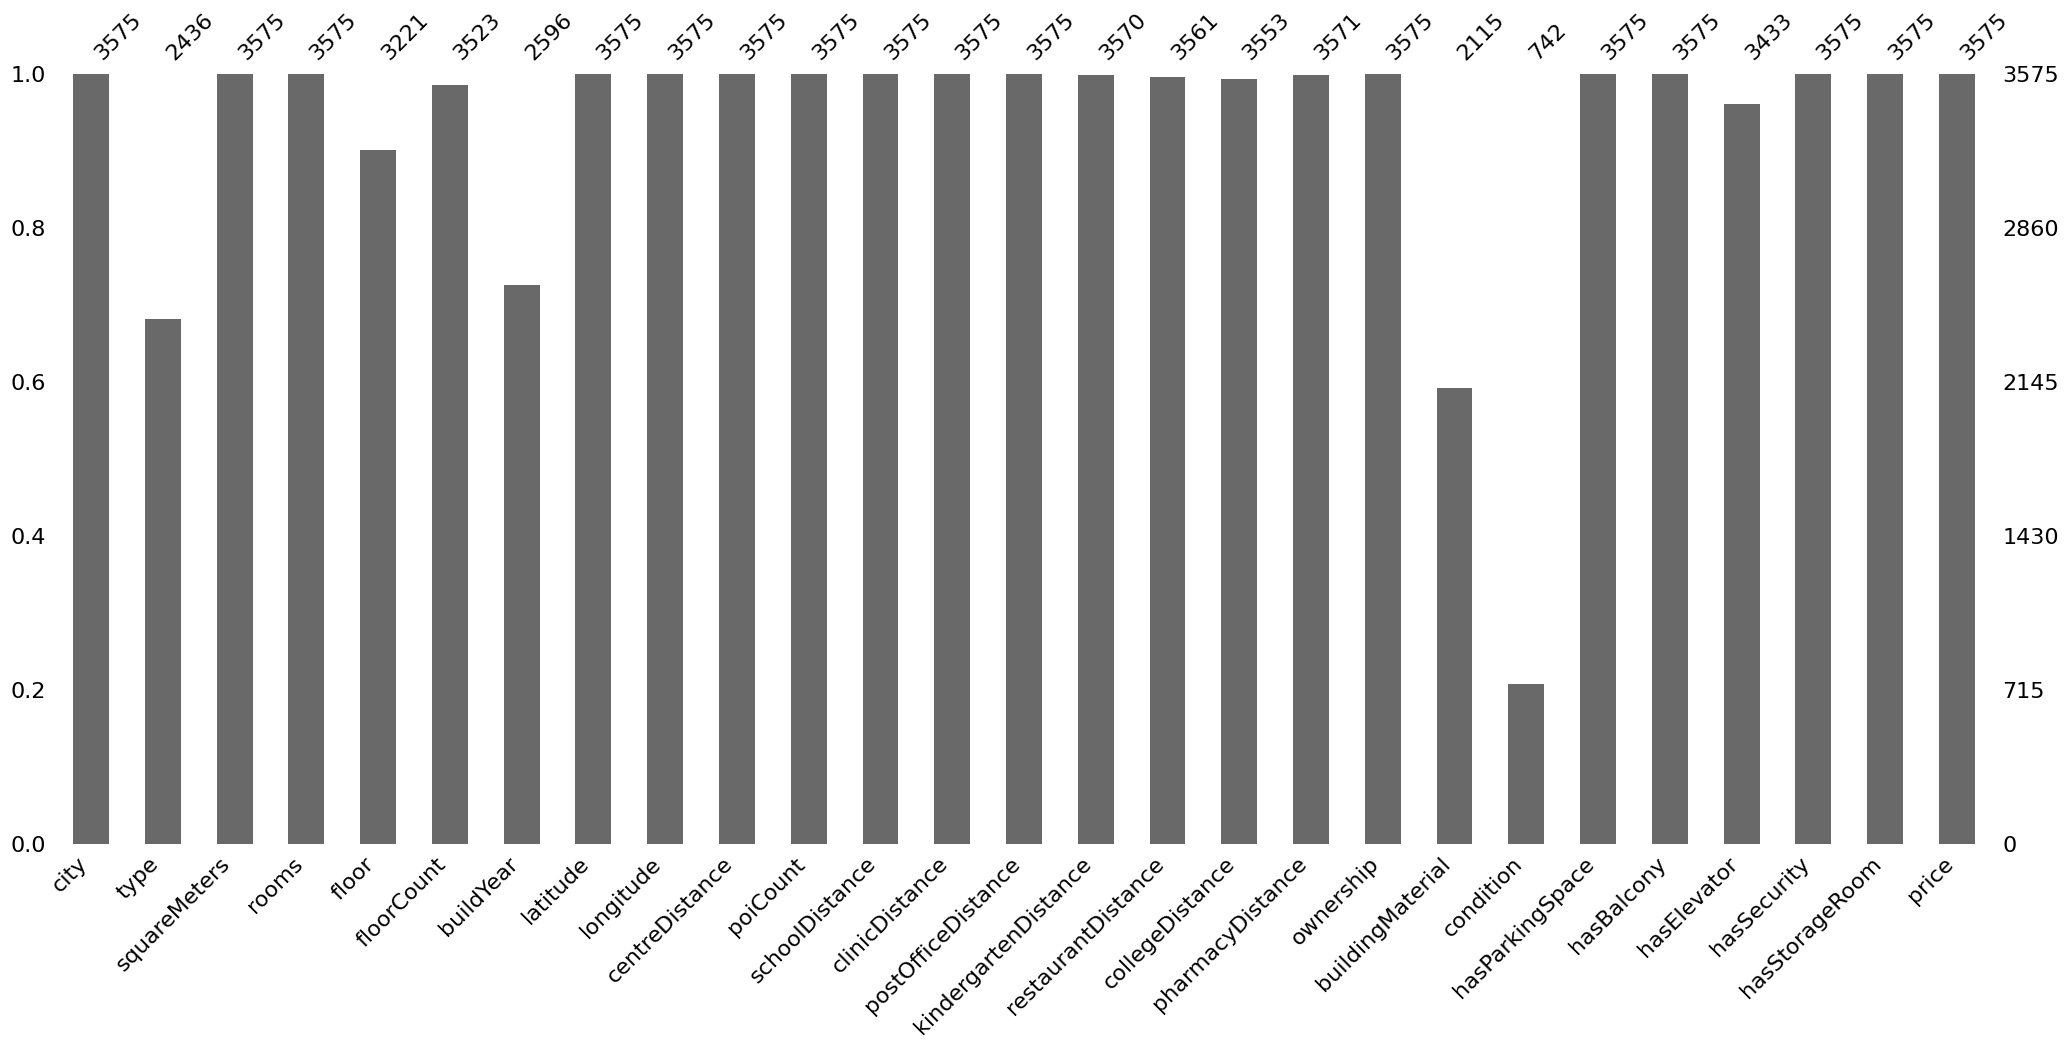

In [11]:

# Aby zwizualizować ilość brakujących danych (NaN) wykorzystamy ich prezentację graficzną na wykresie słupkowym z wykorzystaniem biblioteki missingno.
# Wykres słupkowy prezentuje jak kompletna jest ilość danych w każdej kolumnie w stosunku do ilości maksymalnej równej ilosci wierszy w ramce danych - w naszym przypadku max ilośc danych w kolumnie  to 3575)
msno.bar(df_wawa)
# Na podstawie wykresu widać, że z 11 kolumn z brakującymi danymi największy udytek danych jest w kolumnie 'condition' = 2833.
#Sporo danych jest również pominietych w kolumnach: 'type' = 1139, 'buid year' = 978, 'building material'  = 1460.
# W toku dalszej analizy zdecydujemy "czy" i "jak" będziemy uzupełniać te dane.

<Axes: >

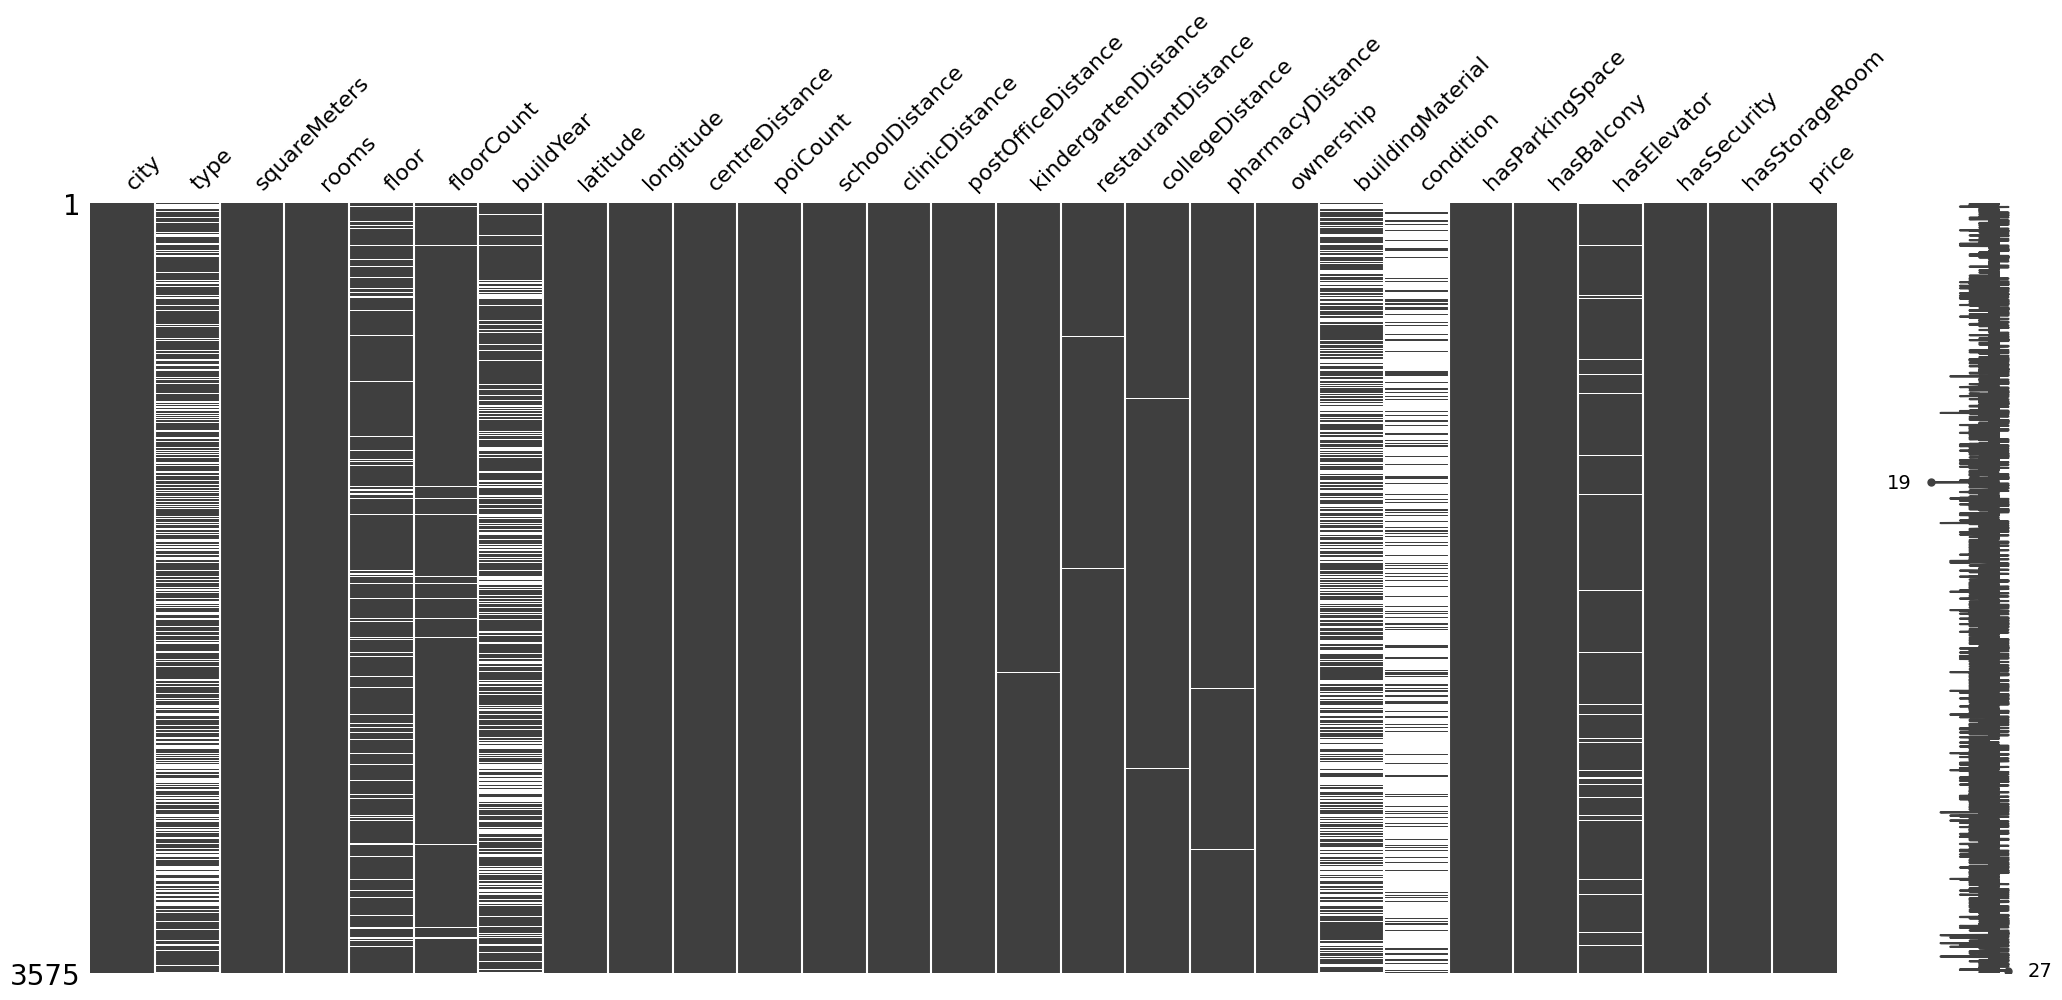

In [176]:
# Kolejny krok to graficzna reprezentacaj rozłożeia brakujących danych.
# W pierwszej kolejności wykorzystamy z wykresu matrix biblioteki missingno
msno.matrix(df_wawa)
#Na tej podstawie można zauważyć, że duży ubytek danych w 4 ww. seriach daych (kolumnach). Ich rozkład jest raczej przypadkowy i w kolejnych krokach analizy należy poszukać ewentualnych korelacji między nimi.
# Na podstawie wykresu ze skrajnej prawej strony można odczytać, ze minimalna ilość danych w wierszu danych to 19.

<Axes: >

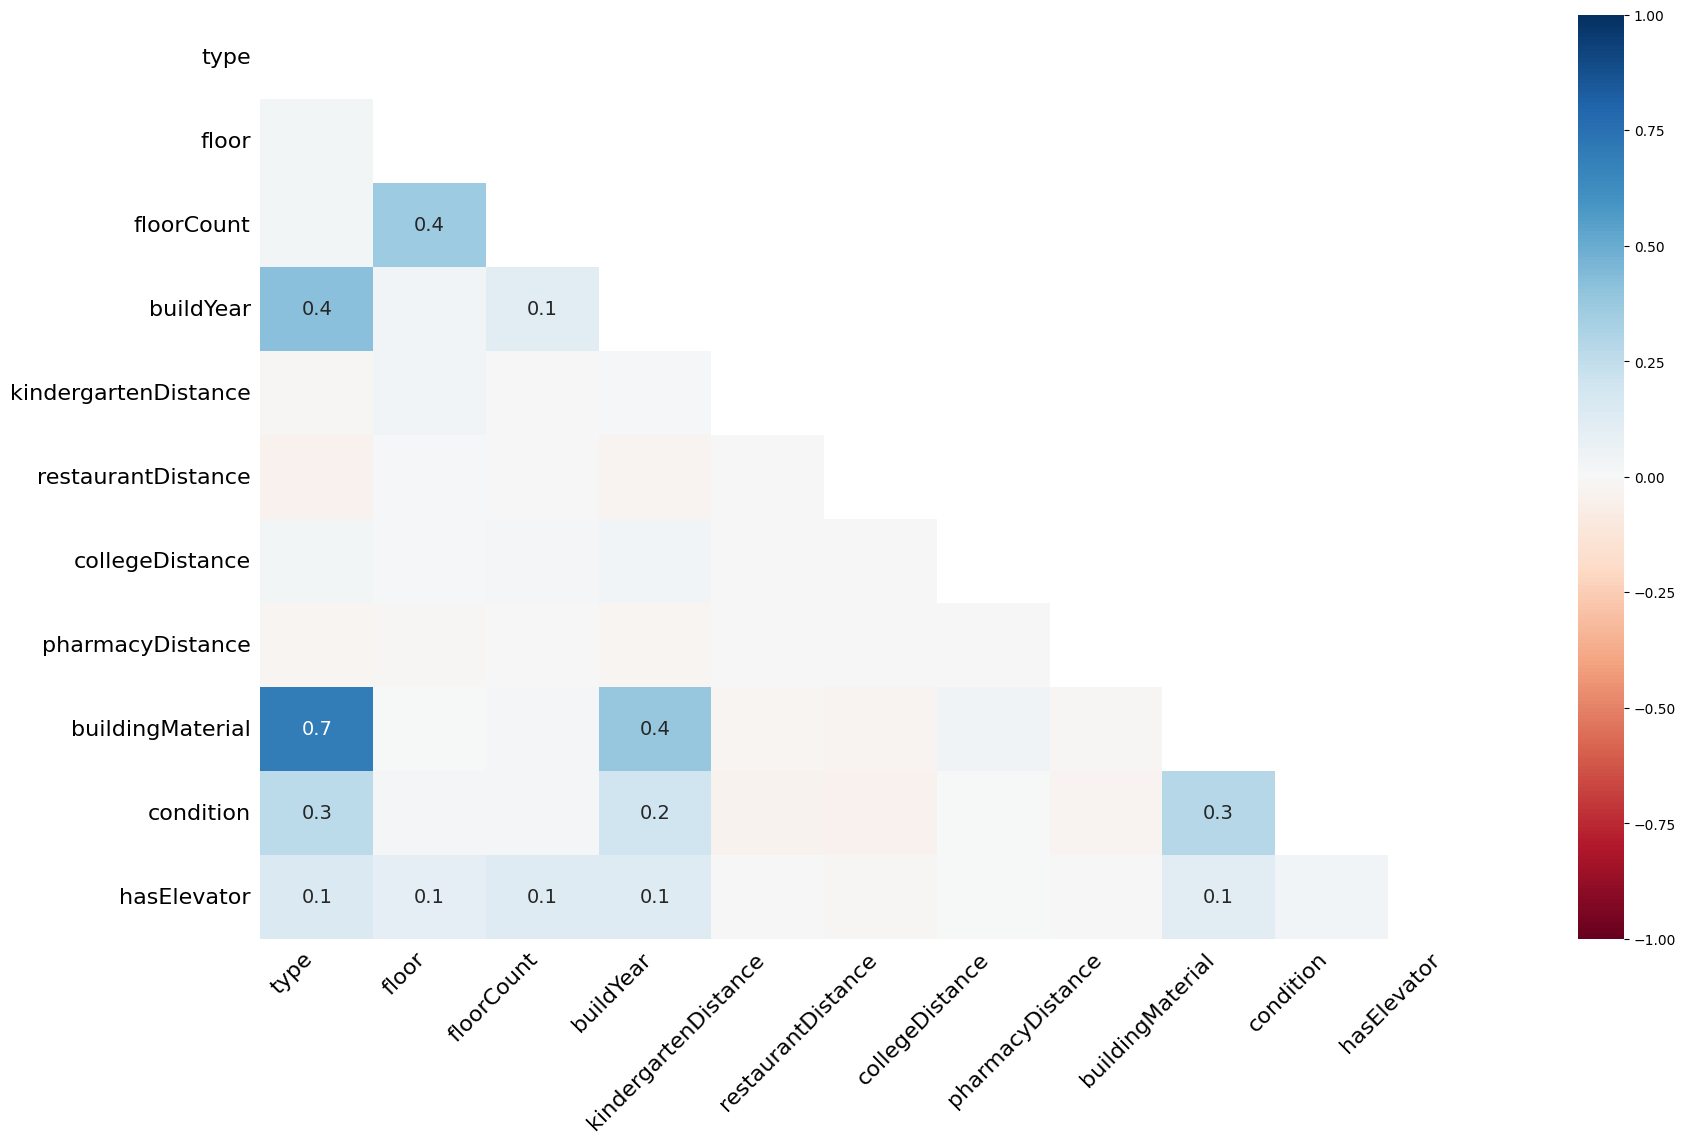

In [177]:
# Kolejny krok to graficzna prezentacja korelacji pomiędzy brakującymi danymi w kolumnach. Analiza korelacji danych została wykonana z wykorzystaniem "mapy ciepła" z biblioteki missingno, która analizuje wzajemną korelację analizowanych cech.
msno.heatmap(df_wawa)
# Podstawie mapy ciepła widać silną korelację pomiędzy brakiem danych (NaN) pomiedzy "buildingMaterial" oraz "type". A także zauważalną korelacje braku danych pomiędzy: "build year" oraz "type", "flor Count" oraz "flor"i w końcu pomiedzy "buildYear" oraz "buildMaterial".
# Można założyć, z osoby wynajmujące apartament celowo nie publikują, brak ww. danych, bo mogły by one wskazywać, że apartament jest już "wiekowy", zbudowany w starej technologii a co się z tym wiąże jego typ ciężko jest zakwalifikować do najczęściej używanych typów lokali.
# Dodatkowo brak danych o ilość pięter w stosunku do ilości pięter w budynku może wskazywać na położenie na wyższych kondygnacjach lub na poddaszu. Co dodatkowo może wskazuje na korelację z brakiem danych dotyczących typu apartamentu.

<Axes: >

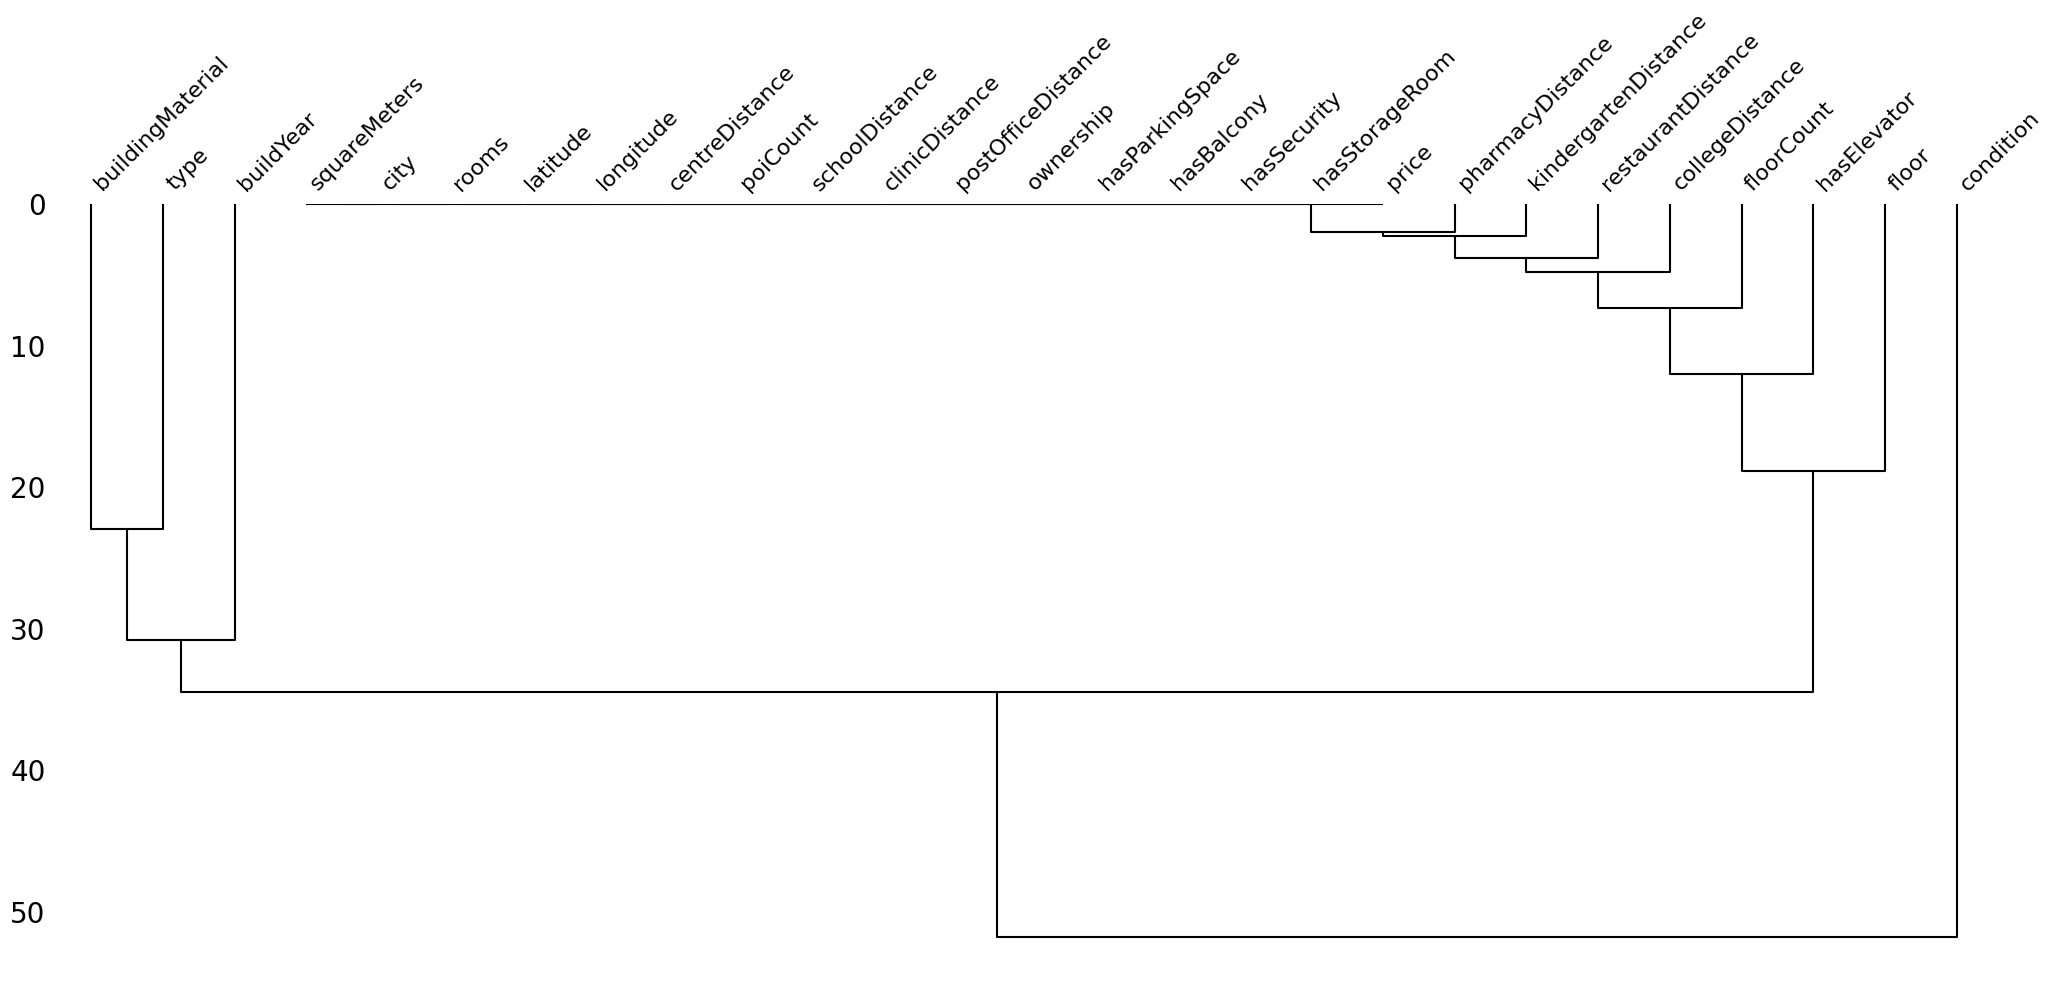

In [178]:
# Ostatnim wykresem badającym korelację braku danych w pakiecie missingno jest dedrogram, który grupuje kolumny o silnych korelacjach wartosci NaN.
msno.dendrogram(df_wawa)
# Dendrogram jest wyraźnie podzielony na 5 odrebne strefy, siłę korelacji odczytujemy od wartosci 0:
# 1 strefa (od 'squareMeters' do 'price')  jest oparta o wartość 0, zawiera kompletne dane, co oczywiście zapewnia silną korelację pomiędzy nimi.
# 2 strefa (od 'buildingMaterial' do 'buildYear') tworzą rdzeń problemu. Mają najwyższe braki (10–40%) i najsilniejsze korelacje (0.3–0.7). Ogłoszeniodawca pomija opis fizyczny budynku, co może sugerować, że nie jest on atrakcyjny.
# 3 strefa (od 'pharmacyDistance' do 'collegeDistance') Skupienie w dendrogramie wynika z podobnego, bardzo niskiego poziomu braków (wykres bar: ~0,5–1,5%), a nie z prawdziwej korelacji braków. Skupiają się w drzewie, bo są podobnie pełne nie dlatego, że brakuje im wspólnych danych. Heatmapa potwierdza: brak korelacji braków między nimi.
# 4 strefa (od 'florCount' do 'flor') mają korelację 0.4 przy niedużych brakach (~10% i <1%). Brak numeru piętra często idzie w parze z brakiem liczby pięter w budynku — logicznie spójne. Może też wskazywać, ze wynajmujący nie chce wskazywać, że apartament jest na wyższych piętrach, choć brak silnej korelacji z hasElevator (0.1)
# 5 strefa ('condition') zawiera najmniejszą ilość danych (742) co wyraźnie wskazuje, że ogłoszeniodawcy niechętnie okreslają stan apartamentu a formularz pozwala na taką dowolność. Z dendrogramu wynika, że ta cech nie koreluje z innymi cechami ale mapa ciepła wskazuje na niską korelację z buildingMaterial (0.3) i buildYear (0.2).

**Wnioski:**

Trzy wykresy razem wskazują na jeden dominujący problem: **opis fizyczny nieruchomości**.

W danych dotyczących: *buildingMaterial* brakuje w ~41% rekordów, *type* brakuje w ~32%, *buildYear* brakujew ~27%,  flor brakuje ~10%, i wreszcie w *condition* brakuje aż w ~79%.

Heatmapa potwierdza, że te braki są mocno powiązane: korelacja 0.7 między *buildingMaterial* a *type*, korelacja 0.4 między *buildingMaterial* a *buildYear* oraz korelacja 0.4 między *buidYear* a *type*.


To ogłoszeniodawcy — a nie system — pomijają te dane, prawdopodobnie dlatego, że formularz pozwala na ich pominięcie oraz że sami ich nie znają lub nie chcą te dane publikować, bo mogłyby wskazywać na zły stan budynku (np. że jest stary).



**Rekomendacje do usunięcie Nan i imputacji danych**

1. *condition* — 79% braków to za dużo na standardową imputację. Zmienna zostaje usunięta z analizy.

2. *type* oraz *buildingMaterial* — korelacja 0.7 umożliwia imputację wzajemną (jeśli znane jest jedno, można przewidzieć drugie) oraz Imputacja Hot Deck najbliższego sąsiedztwa.

3. *buildYear* — imputacja mediany grupowanej z uwzględnieniem 'type' mieszkania.

4. *floor* oraz *floorCount* —  zastosujemy imputację kolumny 'flor' wartoscią średnią z 'florCount' z ograniczeniem 'floor' ≤ 'floorCount'.

Pozostałe kolumny — brak działań, dane praktycznie kompletne lub znikomy ubytek danych.

In [12]:
# 1. Usunięcie kolumny condition
df_wawa = df_wawa.drop('condition', axis='columns')
df_wawa.head(15)

,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,centreDistance,...,collegeDistance,pharmacyDistance,ownership,buildingMaterial,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price
0,warszawa,tenement,39.80,2.0,2.0,3.0,1939.0,52.216513,21.041474,3.09,...,1.635,0.948,condominium,brick,no,no,no,no,no,3650
1,warszawa,apartmentBuilding,78.00,3.0,6.0,15.0,2008.0,52.245300,20.977900,2.31,...,0.569,0.184,condominium,brick,yes,yes,yes,no,no,5600
2,warszawa,tenement,82.00,3.0,3.0,4.0,1875.0,52.229151,20.990837,0.91,...,1.237,0.132,condominium,brick,no,no,NaN,no,no,6500
3,warszawa,blockOfFlats,89.00,4.0,3.0,3.0,2000.0,52.322375,20.937528,11.04,...,1.414,0.283,condominium,brick,yes,no,no,yes,yes,4500
4,warszawa,NaN,45.23,2.0,2.0,3.0,NaN,52.238990,21.076190,5.01,...,0.264,0.129,condominium,NaN,no,yes,no,no,no,3000
5,warszawa,tenement,50.00,3.0,1.0,3.0,1932.0,52.225329,21.034436,2.22,...,1.111,0.147,condominium,brick,no,yes,no,no,no,3750
6,warszawa,NaN,70.00,3.0,1.0,3.0,2003.0,52.201553,20.958403,4.55,...,1.580,0.152,condominium,NaN,yes,yes,yes,no,no,4500
7,warszawa,NaN,68.00,3.0,NaN,3.0,1903.0,52.252914,21.033938,3.14,...,0.522,0.014,condominium,NaN,no,no,no,no,no,5000
8,warszawa,NaN,79.00,3.0,9.0,12.0,2009.0,52.207391,20.964526,3.79,...,0.839,0.066,condominium,NaN,yes,yes,yes,no,no,5900
9,warszawa,NaN,62.00,3.0,4.0,6.0,2016.0,52.227043,20.955604,3.31,...,0.688,0.108,condominium,NaN,yes,yes,yes,no,no,5000


<Axes: xlabel='type', ylabel='squareMeters'>

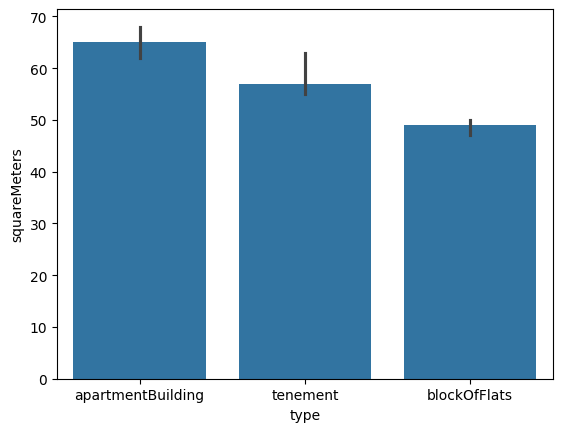

In [13]:
#2. Badamy korelacje danych pomiędzy 'type' a 'squareMeters'. Do badania korelacji przyjęto medianę z uwagi na fakt, że jest odporniejsza na wartości odstające.
sns.barplot(data = df_wawa, x = 'type', y = 'squareMeters', estimator="median", order=('apartmentBuilding', 'tenement','blockOfFlats'))


In [14]:
# Na podstawie ww. wykresów zdecydowano o imputacji zależnej pomiedzy type a squareMeters, wg zależności:
# apartmentBuilding, gdy squareMeters >= 60
# tenement, gdy 40 =< squareMeters < 60
# blockOfFlats, gdy 00 < squareMeters < 40

# W trzech krokach:
# warunek 1: type jest NaN i squareMeters >= 60
df_wawa.loc[df_wawa['type'].isna() & (df_wawa['squareMeters'] >= 60), 'type'] = 'apartmentBuilding'

# warunek 2: type jest NaN i 40 <= squareMeters < 60
df_wawa.loc[df_wawa['type'].isna() & (df_wawa['squareMeters'] >= 40) & (df_wawa['squareMeters'] < 60), 'type'] = 'tenement'

# warunek 3: type jest NaN i 0 < squareMeters < 40
df_wawa.loc[df_wawa['type'].isna() & (df_wawa['squareMeters'] > 0) & (df_wawa['squareMeters'] < 40), 'type'] = 'blockOfFlats'

#print(df_wawa['type'].isna().sum())
df_wawa.head(15)




,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,centreDistance,...,collegeDistance,pharmacyDistance,ownership,buildingMaterial,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price
0,warszawa,tenement,39.80,2.0,2.0,3.0,1939.0,52.216513,21.041474,3.09,...,1.635,0.948,condominium,brick,no,no,no,no,no,3650
1,warszawa,apartmentBuilding,78.00,3.0,6.0,15.0,2008.0,52.245300,20.977900,2.31,...,0.569,0.184,condominium,brick,yes,yes,yes,no,no,5600
2,warszawa,tenement,82.00,3.0,3.0,4.0,1875.0,52.229151,20.990837,0.91,...,1.237,0.132,condominium,brick,no,no,NaN,no,no,6500
3,warszawa,blockOfFlats,89.00,4.0,3.0,3.0,2000.0,52.322375,20.937528,11.04,...,1.414,0.283,condominium,brick,yes,no,no,yes,yes,4500
4,warszawa,tenement,45.23,2.0,2.0,3.0,NaN,52.238990,21.076190,5.01,...,0.264,0.129,condominium,NaN,no,yes,no,no,no,3000
5,warszawa,tenement,50.00,3.0,1.0,3.0,1932.0,52.225329,21.034436,2.22,...,1.111,0.147,condominium,brick,no,yes,no,no,no,3750
6,warszawa,apartmentBuilding,70.00,3.0,1.0,3.0,2003.0,52.201553,20.958403,4.55,...,1.580,0.152,condominium,NaN,yes,yes,yes,no,no,4500
7,warszawa,apartmentBuilding,68.00,3.0,NaN,3.0,1903.0,52.252914,21.033938,3.14,...,0.522,0.014,condominium,NaN,no,no,no,no,no,5000
8,warszawa,apartmentBuilding,79.00,3.0,9.0,12.0,2009.0,52.207391,20.964526,3.79,...,0.839,0.066,condominium,NaN,yes,yes,yes,no,no,5900
9,warszawa,apartmentBuilding,62.00,3.0,4.0,6.0,2016.0,52.227043,20.955604,3.31,...,0.688,0.108,condominium,NaN,yes,yes,yes,no,no,5000


<Axes: xlabel='buildingMaterial', ylabel='count'>

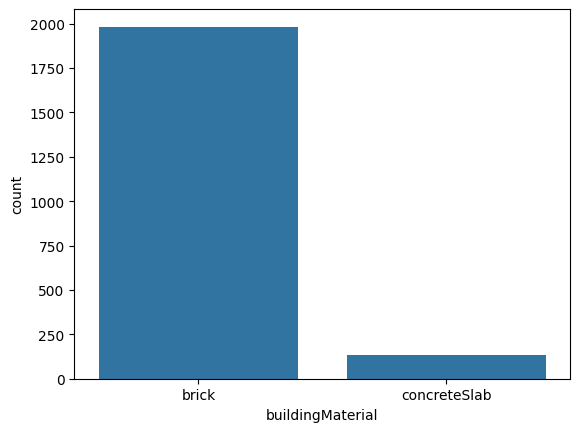

In [15]:
#Badamy ilość poszczególnych typów danych w kolumnie buildingMaterial.
sns.countplot(data = df_wawa, x = 'buildingMaterial')
# Widć wyraźną przewagę w danych mieszkań wykonanych w technologii: 'brick'.
# Ponadto na podstawie heatmap należy podkreślić jednoznaczną i najwyższą korelacje brakujących danych pomiedzy "buildingMaterial" oraz "type" = 0.7.

In [16]:
# Ilość danych = 'concreteSlab' w kolumnie 'buildingMaterial' jest znikoma, stanowią około 4%
df_wawa[df_wawa['buildingMaterial'] == 'concreteSlab']['type'].value_counts()
# Dlatego w toku dalszej analizy podjęto decyzję o imputacji brakujących danych (NaN) w columnie 'buildingMaterial' z wykorzystaniem imputacji losowej Hot_Deck, która powinna zachować rozkład danych, mając na uwadze, że braki są losowe.



,count
type,
blockOfFlats,110
apartmentBuilding,17
tenement,5


In [17]:
# Imputacja losowa Hot Deck, definicja funkcji
def random_hot_deck_imputation(df, column):
    # Filtrujemy wartości nie-null
    non_null_values = df[column].dropna().values
    # Zastępujemy NaN losową wartością z istniejących
    df[column] = df[column].apply(lambda x: np.random.choice(non_null_values) if pd.isna(x) else x)
    return df

# Imputacja dla kolumny 'buildingMaterial'
df_titanic = random_hot_deck_imputation(df_wawa, 'buildingMaterial')
df_wawa['buildingMaterial'].isna().sum()

np.int64(0)

<Axes: xlabel='buildingMaterial', ylabel='count'>

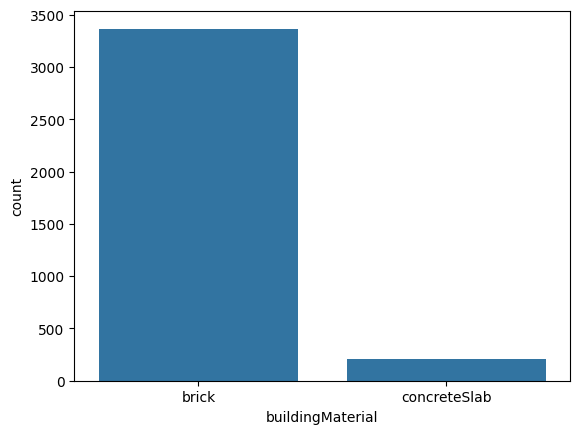

In [18]:
# Ponownie badamy ilość poszczególnych typów danych w kolumnie buildingMaterial. Widać znaczący wzrost ilości danych 'brick' oraz prawie niezauważalny wzrost danych 'concreteSlab'.
sns.countplot(data = df_wawa, x = 'buildingMaterial')

In [19]:
# Ilość danych = 'concreteSlab' w kolumnie 'buildingMaterial' wzrosła nieznacznie ale dalszym ciągu jest znikoma, stanowią około 6% co nie wpłynęło znacąco na rozkład danych
df_wawa[df_wawa['buildingMaterial'] == 'concreteSlab']['type'].value_counts()

,count
type,
blockOfFlats,135
apartmentBuilding,40
tenement,34


In [20]:
# 3. Dla 'buildYear' — wykonamy imputacja mediany grupowanej po 'type', tzn wyliczymy medianę z 'buildYear' dla różnych 'type'.
median_apartments   = df_wawa.loc[df_wawa['type'] == 'apartmentBuilding',   'buildYear'].median()
median_tenement     = df_wawa.loc[df_wawa['type'] == 'tenement',     'buildYear'].median()
median_blockOfFlats = df_wawa.loc[df_wawa['type'] == 'blockOfFlats', 'buildYear'].median()

print(f"apartments:   {median_apartments:}")
print(f"tenement:     {median_tenement:}")
print(f"blockOfFlats: {median_blockOfFlats:}")




apartments:   2010.0
tenement:     1950.0
blockOfFlats: 1999.0


In [21]:
# Następnie zastepujemy wartosci NaN w 'buildYear' zmiennymi z wyliczoną wartoscią mediany dla danego typu mieszkania
df_wawa.loc[(df_wawa['type'] == 'apartmentBuilding') & df_wawa['buildYear'].isna(), 'buildYear'] = median_apartments
df_wawa.loc[(df_wawa['type'] == 'tenement') & df_wawa['buildYear'].isna(), 'buildYear'] = median_tenement
df_wawa.loc[(df_wawa['type'] == 'blockOfFlats') & df_wawa['buildYear'].isna(), 'buildYear'] = median_blockOfFlats

df_wawa[['type','buildYear']].head(20)

,type,buildYear
0,tenement,1939.0
1,apartmentBuilding,2008.0
2,tenement,1875.0
3,blockOfFlats,2000.0
4,tenement,1950.0
5,tenement,1932.0
6,apartmentBuilding,2003.0
7,apartmentBuilding,1903.0
8,apartmentBuilding,2009.0
9,apartmentBuilding,2016.0


In [22]:
# 4. Ponieważ kolumny 'floor' jest zależna od 'floorCount' tzn. 'flor' musi być zawsze mniejsze od 'florCount'. Zastosujemy imputację kolumny 'flor' wartoscią średnią z 'florCount' z ograniczeniem 'floor' ≤ 'floorCount'.
# Warto zauważyć, że 'floorCount'ma bardzo mały ubytek danych i nie będzie podlegała imputacji.

# Wylicz średnią 'floor' w grupach wg 'floorCount'
df_wawa['floor'] = df_wawa['floor'].fillna(df_wawa.groupby('floorCount')['floor'].transform('mean'))
# Wszędzie gdzie floor >= floorCount — zastąp wartością floorCount - 1
df_wawa.loc[df_wawa['floor'] >= df_wawa['floorCount'], 'floor'] = df_wawa['floorCount'] - 1

# Jeśli w tych samych wierszach 'floor' oraz 'floorCount' występuję NaN, to uzupełniamy 'floor' na podstawie najbliżsej wartosci poprzedzającej lub nastepującej po danej.
df_wawa['floor'] = df_wawa['floor'].ffill()
df_wawa['floor'] = df_wawa['floor'].bfill()

# Zaokrąglenie do jednego miejsca po przecinku, nie zmienamy typu danych
df_wawa['floor'] = df_wawa['floor'].astype(float).round(1)

df_wawa[['floor','floorCount']].head(20)



,floor,floorCount
0,2.0,3.0
1,6.0,15.0
2,3.0,4.0
3,2.0,3.0
4,2.0,3.0
5,1.0,3.0
6,1.0,3.0
7,2.0,3.0
8,9.0,12.0
9,4.0,6.0


In [23]:
# Weryfikujemy skuteczność przyjętej metody imputacji.
df_wawa[['floor','floorCount']].isna().sum()

,0
floor,0
floorCount,52


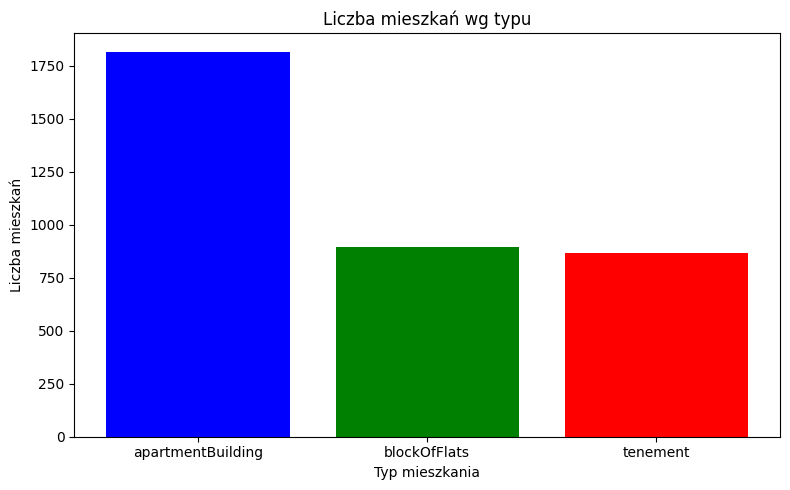

In [24]:
# Poniżej wykres słupkowy prezentujący ilość różnych typów mieszkań na wynajem w Warszawie

# Przypisanie danych do zmiennej
liczba = df_wawa['type'].value_counts()

#Rysowanie wykresu
plt.figure(figsize=(8, 5))
plt.bar(liczba.index, liczba.values, color=['blue', 'green', 'red'])

#Opis osi wykresu
plt.xlabel('Typ mieszkania')
plt.ylabel('Liczba mieszkań')
plt.title('Liczba mieszkań wg typu')
plt.tight_layout()
plt.show()

#Widac na nim wyraźną przewage mieszkań typu apartmentBuilding

<Figure size 1000x600 with 0 Axes>

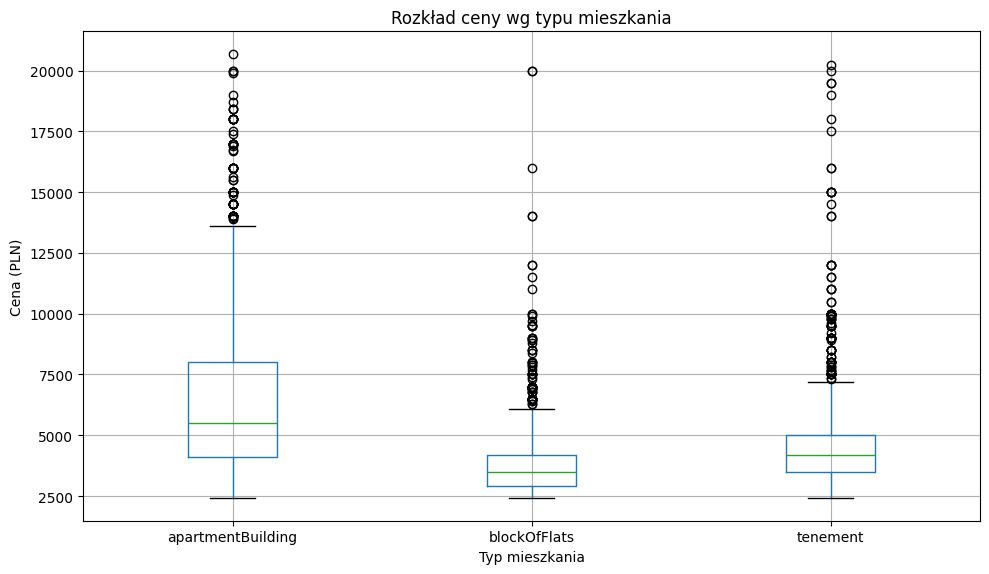

In [30]:
# Poniżej wykres boxplot prezentujący zależność ceny 'price' od typu wynajmowanego mieszkania: 'apartmentBuilding', 'tenement', 'blockOfFlats'
# Rysowanie wykresu
plt.figure(figsize=(10, 6))
df_wawa.boxplot(column='price', by='type', figsize=(10, 6))

# Opis osi wykresu
plt.xlabel('Typ mieszkania')
plt.ylabel('Cena (PLN)')
plt.title('Rozkład ceny wg typu mieszkania')
plt.suptitle('')
plt.tight_layout()
plt.show()


<Figure size 1400x600 with 0 Axes>

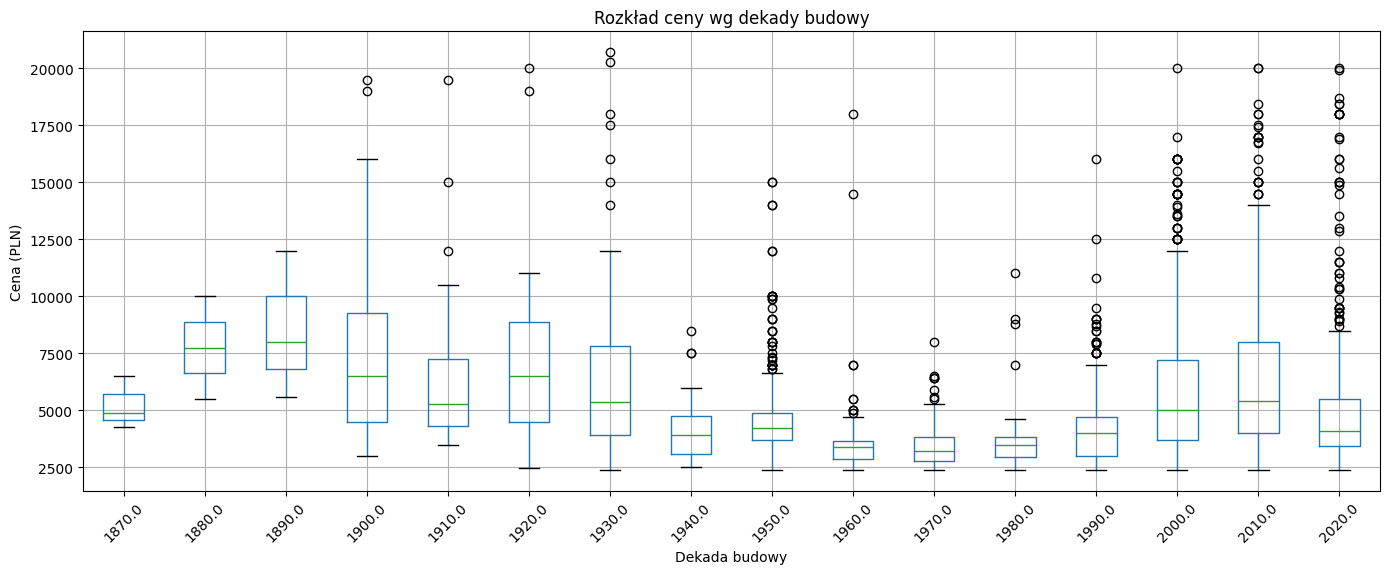

In [201]:
# Po uzupełnieniu pdstawoowych danych przygotowałem wykres wizualizujący zależność pomiędzy rokiem budowy mieszkania na wynajem a jego ceną.
# Dla większej czytelności dane zostały przedstawione z podziałem na dekady.

# Tworzenie kolumny z dekadami
df_wawa['dekada'] = (df_wawa['buildYear'] // 10 * 10).astype(str)

# Tworzenie wykresu
plt.figure(figsize=(14, 6))
df_wawa.boxplot(column='price', by='dekada', figsize=(14, 6))

# Opisy osi wykresu itd.
plt.xlabel('Dekada budowy')
plt.ylabel('Cena (PLN)')
plt.title('Rozkład ceny wg dekady budowy')
plt.suptitle('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Wnioski końcowe.**
W zadaniu skupiłem się na analizie danych pod kontem ich braku NaN oraz imputacji danych z wykorzystaniem róznych metod imputacji lub ich prostego uzupełnienia.

W mojej ocenie dobrze sprawdziła sie imputacja danych w oparciu obserwacje zalezności pomiędzy danymi w różnych kolumnach w szczególnosci metoda imputacji losowej nie wpłynęła znacząco na rozkład danych.


W toku dalszej analizy uzupełnoinych danych na wykresach przedstawiłem:

Wykres 1

Wykres słupkowy wyraźną przewagę ilości mieszkań typu apartmentBuilding, co może się wydawać naturalne w mieście takim jak Warszawa.

Wykres 2.

Wykres boxplot.
Wszystkie trzy typy mieszkań na wykresie, w szczególności 'apartmentBuilding' wykazują skośność prawostronną i outliery w górze oraz brak outlierów na dole — to typowy wzorzec rynku nieruchomości gdzie istnieje segment luksusowy, a Warszawa jak wykazaliśmy na wykresie słupkowym jest  rynkiem zdominowanym przez 'apartmentBuilding.
Ponadto porównanie median wskazuje jednoznaczną hierarchię cenową: apartmentBuilding > tenement > blockOfFlats.

Natomiast porównuując IQR  można okreśić, który z typu wmieszkań jest najtrudniejszy do wyceny.  Szerokie pudełko = duże zróżnicowanie cen. Wąskie = rynek jednorodny. Mając to na uwadze można określić hierarchię pod względem łatwości wyceny: apartmentBuilding > tenement > blockOfFlats. Jeśli jednak uwzględnimy dość licznie występujące outliery to moim zdaniem najtrudniejsze do wyceny są tenement, gdzie rozrzut wartości jest największy.

Przy wyciąganiu wniosków z analizy ceny 'price' warto potraktować 'type' jako zmienną, która w istotny sposób wpływa różnice między medianami, które są duże i statystycznie uzasadnione. Jednocześnie szerokość pudełek, szczególnie dla tenement, sugeruje że sama przynależność do typu to za mało — potrzebne są dodatkowe zmienne np. buildYear, żeby dobrze wyjaśnić wariancję wewnątrz każdej kategorii.

Wykres3.

Wykres boxplot.
Przedsawiłem wzajemną korelację zalezności ceny'price' wynajmu od roku budowy 'buildYear'.
Na podsatwie wykresu widac wyraźną zależność ceny mieszkania od roku jego budowy, przy czym wyraźny spadek wartości ceny wynajmu dotyczy  mieszkań zbudowanych w latach 1940 do 2000, najprawdopodobniej dotyczy to wielokondygnacyjnych budynków (bloków) zbudowanych w okresie PRL i znajdujących się po za centrum Warszawy.
Natomiast nowe budownictwo oraz stare kamienice, znajdujące się w centrum, co stanowi o ich atrakcyjności pod wynajem, zdecydowanie "trzymają" wysoką cenę.
W przypadku najnowszych mieszkań na wynajem widać wyraźną grupę outlier'ów, które stanowią luksusowe apartamenty wybudowane np. na z zamknietych osiedlach, ktorych wiele powastało w Warszawie po 2000 roku.


Dalasza analiza ceny 'price' od innych czynników jak 'centreDistance' lub 'buildYear' może dostarczyć dodatkowych wniosków dotyczących czynników wpływających na cenę wynajmu mieszkania poza tak oczywistymi jak 'squareMeters" czy 'rooms'.